In [55]:
import jax.numpy as jnp
from scipy.stats import norm, beta, binom
import matplotlib.pyplot as plt
import random

# Beta-Binomial model

## Prior and likelihood

In [48]:
#Likelihood#
N = 20 #Total trails
y = 4 #Successes

#Prior#
a0 = 2
b0 = 2

## Prior mean

### Equation

$$\mathbb{E}[\theta] = \frac{a_{0}}{a_{0} + b_{0}}$$

### Code

In [49]:
prior_mu = a0 / (a0+b0)
prior_mu

0.5

## Posterior parameters

### Equation

$$p(\theta | y) = \text{Beta}(\theta | a_{0} + y, b_{0} + N - y)$$

### Code

In [50]:
a = a0 + y
b = b0 + N - y

## Posterior mean

### Equation

$$\mathbb{E}[\theta | y] = \frac{a}{a + b} = \frac{a_{0} + y}{a_{0} + b_{0} + N}$$

### Code

In [52]:
mu_post = a / (a+b)
mu_post

0.25

## Comparing beta distribution A against beta distribution B

We sample $\theta_{A}$ from posterior A and sample $\theta_{B}$ from posterior B and compute $\theta_{D} = \theta_{B} - \theta_{A}$

In [61]:
#Define parameters for two posterior
N_1 = 123
N_2 = 145

y_1 = 12
y_2 = 20

#Define prior variables
a_0 = 1
b_0 = 1

#Computation of posterior varibales
a_1 = a0 + y_1
a_2 = a0 + y_2

b_1 = b0 + N_1 - y_1
b_2 = b0 + N_2 - y_2


### Sample $\theta$ from the two distributions

In [78]:
theta_1 = beta.rvs(a = a_1, b = b_1, size = 10000)
theta_2 = beta.rvs(a = a_2, b = b_2, size = 10000)

theta_D = theta_2 - theta_1

### Histogram of $\theta_D$

(array([  3.,   2.,   2.,   6.,   7.,   8.,  12.,  15.,  27.,  30.,  40.,
         57.,  58., 105., 149., 170., 199., 255., 313., 349., 432., 483.,
        534., 559., 573., 574., 604., 577., 574., 530., 429., 410., 398.,
        348., 253., 233., 179., 125., 100.,  92.,  59.,  39.,  29.,  18.,
         12.,   9.,   7.,   6.,   3.,   4.]),
 array([-0.11518088, -0.10929288, -0.10340489, -0.0975169 , -0.0916289 ,
        -0.08574091, -0.07985292, -0.07396492, -0.06807693, -0.06218894,
        -0.05630094, -0.05041295, -0.04452496, -0.03863696, -0.03274897,
        -0.02686098, -0.02097298, -0.01508499, -0.009197  , -0.003309  ,
         0.00257899,  0.00846699,  0.01435498,  0.02024297,  0.02613097,
         0.03201896,  0.03790695,  0.04379495,  0.04968294,  0.05557093,
         0.06145893,  0.06734692,  0.07323491,  0.07912291,  0.0850109 ,
         0.09089889,  0.09678689,  0.10267488,  0.10856287,  0.11445087,
         0.12033886,  0.12622685,  0.13211485,  0.13800284,  0.14389083,
 

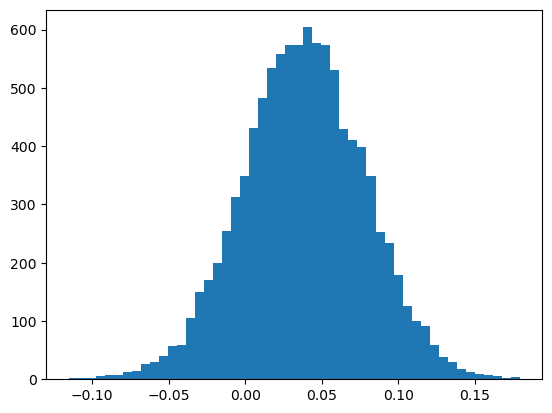

In [79]:
plt.hist(theta_D, bins = 50)

### Expectation of $\theta_{D}$: $\mathbb{E}[\theta | \mathcal{D}]$

In [81]:
jnp.mean(theta_D)

Array(0.03809166, dtype=float32)

### Probability that $\theta_{B} > \theta_{A}$

In [80]:
jnp.mean(theta_D > 0)

Array(0.8355, dtype=float32)

### Credibility interval

In [83]:
jnp.quantile(theta_D,jnp.array([0.025, 0.975]))

Array([-0.04023509,  0.11602516], dtype=float32)